In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
def calc_dphi(phi1, phi2):
    dphi = phi2 - phi1
    dphi[dphi > np.pi] -= 2*np.pi
    dphi[dphi < -np.pi] += 2*np.pi
    return dphi

In [4]:
input_dir = './MPD_events'
rmaxlist = []
zminlist = []
zmaxlist = []
maxrowlist = []
minrowlist = []
particlenumlist = []
hitnumlist = []

distance_list = []

for evtid in range(100):
    event_name = input_dir + f'/event_{evtid}_'
    print(f'Processing: {event_name:s}')

    hits = pd.read_csv(event_name + 'hits.csv')
    if not hits.empty:
        r = np.sqrt(hits.x**2 + hits.y**2)
        phi = np.arctan2(hits.y, hits.x)
        hits = hits[['hit_id', 'z', 'row_id', 'sector_id']].assign(r=r, phi=phi)
        rmaxlist.append(hits['r'].max())
        zminlist.append(hits['z'].min())
        zmaxlist.append(hits['z'].max())
        minrowlist.append(hits['row_id'].min())
        maxrowlist.append(hits['row_id'].max())
        hitnumlist.append(len(hits))

    tracks = pd.read_csv(event_name + 'tracks.csv')
    if not tracks.empty:
        particlenumlist.append(len(set(tracks['track_id'])))

    truth = pd.read_csv(event_name + 'truth.csv')

    truth = truth.merge(tracks[['track_id', 'pt']], on='track_id')
    hits = hits.merge(truth, on='hit_id')

    hits = hits[hits['pt'] > 0.05]

    hit_gropus = hits.groupby("track_id")

    for x in set(hits['track_id']):
        track_df = hit_gropus.get_group(x).assign(evtid=evtid)
        if len(track_df) > 1:
            merged = track_df.merge(track_df, on=['track_id', 'sector_id'],
                                    suffixes=('_1', '_2'))

            mask = ((merged['hit_id_1'] != merged['hit_id_2']) &
                    (0 < abs(merged['row_id_1'] - merged['row_id_2'])) &
                    (abs(merged['row_id_1'] - merged['row_id_2']) <= 3))
            pairs = merged[mask].copy()

            if not pairs.empty:
                dphi = calc_dphi(pairs.phi_1, pairs.phi_2)
                dz = pairs.z_2 - pairs.z_1
                distance = np.sqrt(pairs.r_1**2 + pairs.r_2**2 -
                                   2 * pairs.r_1 * pairs.r_2 * np.cos(dphi) + dz**2)
                pairs['distance'] = distance

                forward_pairs = pairs[pairs['row_id_2'] > pairs['row_id_1']]
                backward_pairs = pairs[pairs['row_id_2'] < pairs['row_id_1']]

                if not forward_pairs.empty:
                    idx_fwd = forward_pairs.groupby('hit_id_1')['distance'].idxmin()
                    nearest_fwd = forward_pairs.loc[idx_fwd, ['hit_id_1', 'hit_id_2', 'distance']].rename(columns={'hit_id_1': 'hit_id'})
                    distance_list.extend(nearest_fwd['distance'].tolist())

                if not backward_pairs.empty:
                    idx_bwd = backward_pairs.groupby('hit_id_1')['distance'].idxmin()
                    nearest_bwd = backward_pairs.loc[idx_bwd, ['hit_id_1', 'hit_id_2', 'distance']].rename(columns={'hit_id_1': 'hit_id'})
                    distance_list.extend(nearest_bwd['distance'].tolist())

Processing: ./MPD_events/event_0_
Processing: ./MPD_events/event_1_
Processing: ./MPD_events/event_2_
Processing: ./MPD_events/event_3_
Processing: ./MPD_events/event_4_
Processing: ./MPD_events/event_5_
Processing: ./MPD_events/event_6_
Processing: ./MPD_events/event_7_
Processing: ./MPD_events/event_8_
Processing: ./MPD_events/event_9_
Processing: ./MPD_events/event_10_
Processing: ./MPD_events/event_11_
Processing: ./MPD_events/event_12_
Processing: ./MPD_events/event_13_
Processing: ./MPD_events/event_14_
Processing: ./MPD_events/event_15_
Processing: ./MPD_events/event_16_
Processing: ./MPD_events/event_17_
Processing: ./MPD_events/event_18_
Processing: ./MPD_events/event_19_
Processing: ./MPD_events/event_20_
Processing: ./MPD_events/event_21_
Processing: ./MPD_events/event_22_
Processing: ./MPD_events/event_23_
Processing: ./MPD_events/event_24_
Processing: ./MPD_events/event_25_
Processing: ./MPD_events/event_26_
Processing: ./MPD_events/event_27_
Processing: ./MPD_events/event

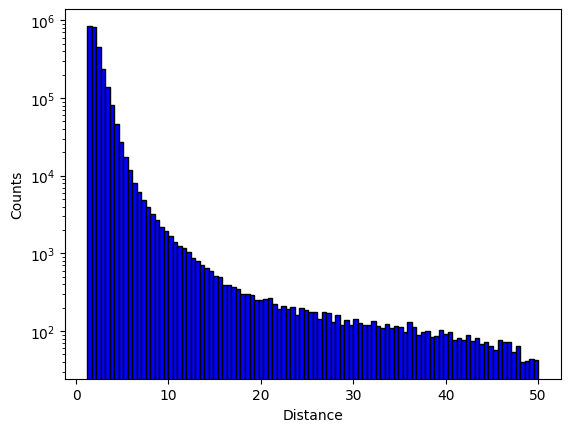

In [8]:
distance_array = np.array(distance_list)

plt.hist(distance_array[distance_array < 50], bins=100, color='blue', edgecolor='black')

plt.ylabel('Counts')
plt.xlabel('Distance')
plt.yscale('log')

plt.show()

In [7]:
len(distance_array[distance_array < 7.5])/len(distance_array)

0.9854900441666086

In [27]:
np.array(rmaxlist).max()

np.float64(122.9716049771247)

In [28]:
np.array(zminlist).min()

np.float64(-166.489)

In [29]:
np.array(zmaxlist).max()

np.float64(166.61)

In [30]:
np.array(minrowlist).min()

np.int64(0)

In [31]:
np.array(maxrowlist).max()

np.int64(52)

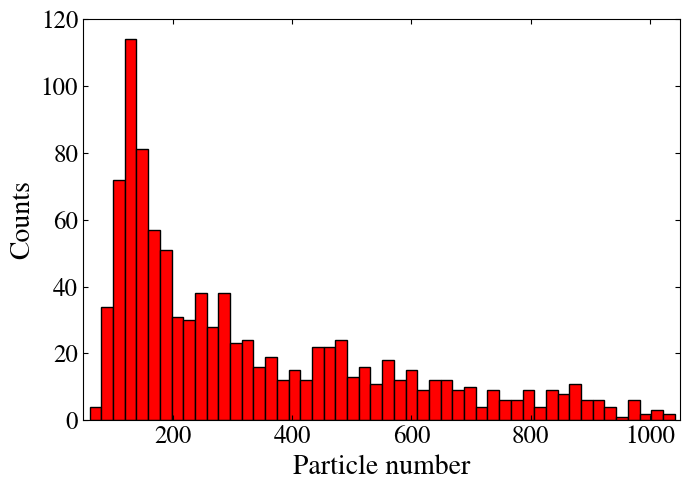

In [22]:
with plt.rc_context({'font.family': 'Nimbus Roman'}):
    plt.figure(figsize=(7, 5))
    plt.hist(particlenumlist, bins=50, color='red', edgecolor='black')
    plt.ylabel('Counts', fontsize=20)
    plt.xlabel('Particle number', fontsize=20)
    plt.xlim([50, 1050])
    plt.ylim([0, 120])
    plt.tick_params(axis='both', 
                        which='major', 
                        labelsize=18,
                        top=True,
                        bottom=True,
                        left=True,
                        right=True,
                        direction='in')
    plt.tight_layout()
    plt.show()
    #plt.savefig("Particle_number.pdf")

In [26]:
print(f'{len([x for x in particlenumlist if x > 400]) / len(particlenumlist) * 100:.2f}%')

32.10%


In [25]:
sum(particlenumlist) / len(particlenumlist)

335.52

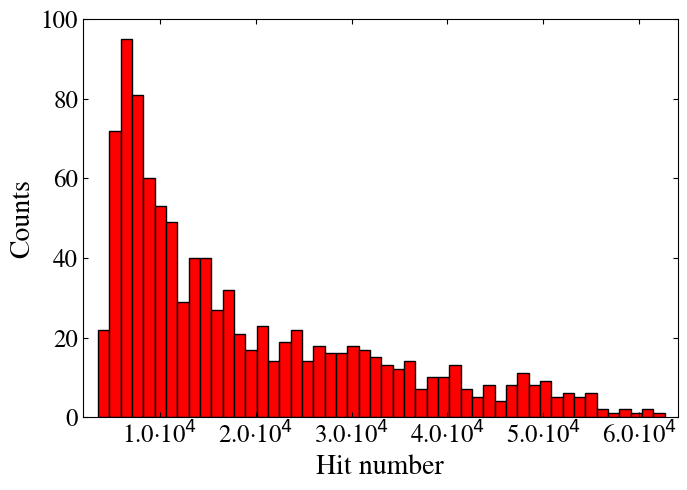

In [23]:
with plt.rc_context({'font.family': 'Nimbus Roman'}):
    plt.figure(figsize=(7, 5))
    plt.hist(hitnumlist, bins=50, color='red', edgecolor='black')
    def format_x_ticks(x, pos):
        return f"{x / 1e4:.1f}·10$^4$"
    plt.ylabel('Counts', fontsize=20)
    plt.xlabel('Hit number', fontsize=20)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
    plt.xlim([2000, 64000])
    plt.ylim([0, 100])
    plt.tick_params(axis='both', 
                        which='major', 
                        labelsize=18,
                        top=True,
                        bottom=True,
                        left=True,
                        right=True,
                        direction='in')
    plt.tight_layout()
    plt.show()
    #plt.savefig("Hit_number.pdf")

In [24]:
sum(hitnumlist) / len(hitnumlist)

19001.078